<a href="https://colab.research.google.com/github/AnilJagarapu2704/Projects/blob/main/Untitled18.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **🧩 1️⃣ AeroFit Data Analysis Case Study**

### **Problem Statement**

AeroFit wants to understand the characteristics of customers purchasing each of its treadmill models—KP281, KP481, and KP781. By analyzing customer demographics, fitness levels, and usage behavior, the company aims to identify distinct customer segments and improve product recommendations.

###**Objective**


1.   Analyze customer demographics (age, gender, marital status, income) to understand who purchases AeroFit treadmills.
2.   Examine customer fitness behavior (usage frequency, fitness level, expected miles) to identify usage intensity patterns.
3.   Compare the three treadmill models (KP281, KP481, KP781) to identify differences in customer segments and purchase drivers.
4.   Compute marginal and conditional probabilities to understand the likelihood of different customer groups purchasing each treadmill model.
5.   Develop customer profiles for each treadmill type to support targeted marketing and personalized product recommendations.
6.   Generate actionable business insights to help AeroFit optimize product positioning, pricing, and marketing strategy.







##**🧹 2️⃣ Data Loading & Cleaning**

In [93]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

###**DATA LOADING**

In [94]:
data = pd.read_csv('/content/aerofit_treadmill.csv')

##What is the shape of the table?

It consists of 180 rows and 9 columns

In [95]:
data.shape

(180, 9)

## What are columns in the table?

Product, Age, Gender, Education, MaritialStatus, Usage, Fitness, Income, Miles are the columns in the table

In [96]:
data.columns

Index(['Product', 'Age', 'Gender', 'Education', 'MaritalStatus', 'Usage',
       'Fitness', 'Income', 'Miles'],
      dtype='object')

### **DATA CLEANING**

##Number of null values in each column?

There are no null values in every column

In [98]:
data.isnull().sum()

,0
Product,0
Age,0
Gender,0
Education,0
MaritalStatus,0
Usage,0
Fitness,0
Income,0
Miles,0


## What are data types of each columns?


In [99]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Product        180 non-null    object
 1   Age            180 non-null    int64 
 2   Gender         180 non-null    object
 3   Education      180 non-null    int64 
 4   MaritalStatus  180 non-null    object
 5   Usage          180 non-null    int64 
 6   Fitness        180 non-null    int64 
 7   Income         180 non-null    int64 
 8   Miles          180 non-null    int64 
dtypes: int64(6), object(3)
memory usage: 12.8+ KB


It is better to change "Product", "Gender" and "MaritalStatus" columns from 'object' data type to 'category'.

In [101]:
to_cat = ['Product', 'Gender', 'MaritalStatus']
data[to_cat] = data[to_cat].astype('category')

In [102]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   Product        180 non-null    category
 1   Age            180 non-null    int64   
 2   Gender         180 non-null    category
 3   Education      180 non-null    int64   
 4   MaritalStatus  180 non-null    category
 5   Usage          180 non-null    int64   
 6   Fitness        180 non-null    int64   
 7   Income         180 non-null    int64   
 8   Miles          180 non-null    int64   
dtypes: category(3), int64(6)
memory usage: 9.5 KB


Now all the required columns data type is changed from 'object' data type to 'category' data type.

In [103]:
data.describe(include = 'all')

,Product,Age,Gender,Education,MaritalStatus,Usage,Fitness,Income,Miles
count,180,180.000000,180,180.000000,180,180.000000,180.000000,180.000000,180.000000
unique,3,NaN,2,NaN,2,NaN,NaN,NaN,NaN
top,KP281,NaN,Male,NaN,Partnered,NaN,NaN,NaN,NaN
freq,80,NaN,104,NaN,107,NaN,NaN,NaN,NaN
mean,NaN,28.788889,NaN,15.572222,NaN,3.455556,3.311111,53719.577778,103.194444
std,NaN,6.943498,NaN,1.617055,NaN,1.084797,0.958869,16506.684226,51.863605
min,NaN,18.000000,NaN,12.000000,NaN,2.000000,1.000000,29562.000000,21.000000
25%,NaN,24.000000,NaN,14.000000,NaN,3.000000,3.000000,44058.750000,66.000000
50%,NaN,26.000000,NaN,16.000000,NaN,3.000000,3.000000,50596.500000,94.000000
75%,NaN,33.000000,NaN,16.000000,NaN,4.000000,4.000000,58668.000000,114.750000


## Sample Table

In [104]:
data.head()

,Product,Age,Gender,Education,MaritalStatus,Usage,Fitness,Income,Miles
0,KP281,18,Male,14,Single,3,4,29562,112
1,KP281,19,Male,15,Single,2,3,31836,75
2,KP281,19,Female,14,Partnered,4,3,30699,66
3,KP281,19,Male,12,Single,3,3,32973,85
4,KP281,20,Male,13,Partnered,4,2,35247,47


### **📊 3️⃣ Exploratory Data Analysis (EDA)**

###**1. What are the key demographic characteristics of AeroFit customers?**

## Non-Graphical Analysis

In [105]:
# Number of customers per each product and their Marital Status

cat_wise_sales = data.groupby(['Product', 'MaritalStatus'], observed = False)['Product'].count().reset_index(name = 'Income')
cat_wise_sales.rename(columns = {'Income': 'cust_count'}, inplace = True)
cat_wise_sales

,Product,MaritalStatus,cust_count
0,KP281,Partnered,48
1,KP281,Single,32
2,KP481,Partnered,36
3,KP481,Single,24
4,KP781,Partnered,23
5,KP781,Single,17


## Visual Analysis

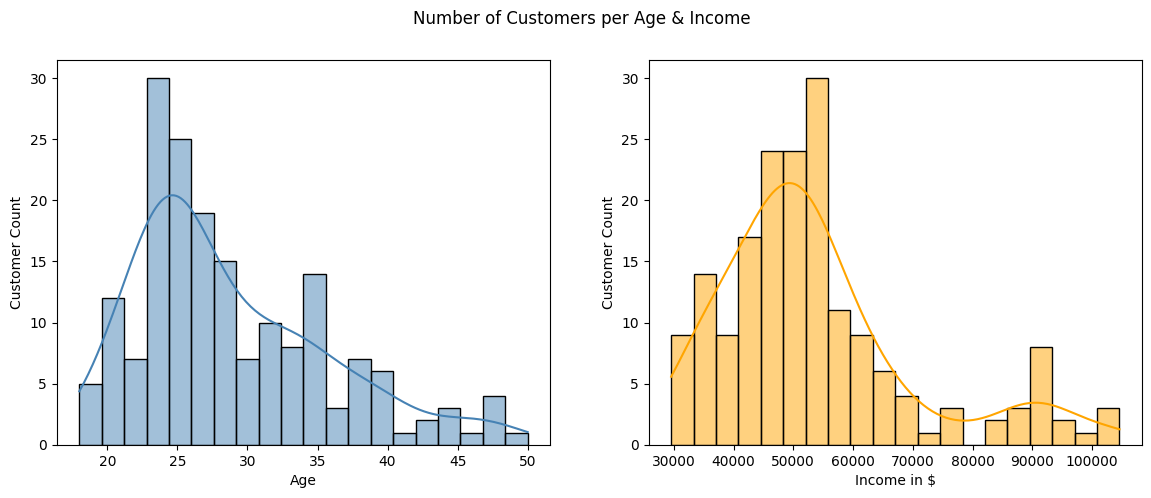

In [106]:
plt.figure(figsize = (14, 5))
plt.subplot(1, 2, 1)
sns.histplot(data['Age'], bins = 20, kde = True, color = 'steelblue')
plt.xlabel('Age')
plt.ylabel('Customer Count')
plt.subplot(1, 2, 2)
sns.histplot(data['Income'], bins = 20, kde = True, color = 'orange')
plt.xlabel('Income in $')
plt.ylabel('Customer Count')
plt.suptitle('Number of Customers per Age & Income')
plt.show()

The provided histograms indicate a broad distribution of customer counts across various age groups and annual income levels. Analysis reveals that younger customers are purchasing treadmills at a higher rate than middle-aged individuals. Interestingly, customers with lower annual incomes show a greater investment in treadmills compared to those in higher income brackets.

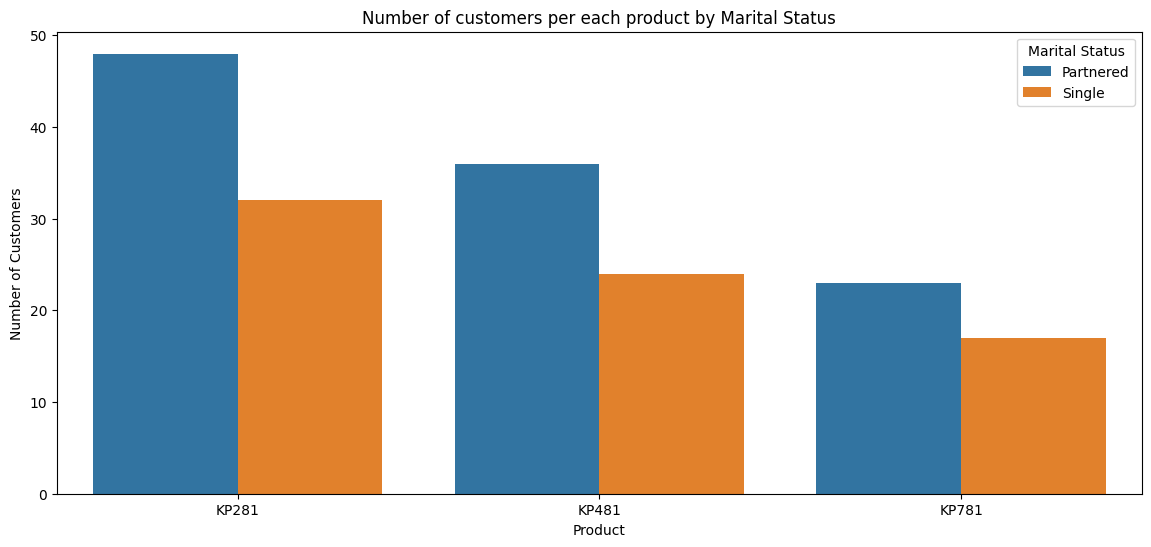

In [108]:
plt.figure(figsize = (14, 6))
sns.barplot(data = cat_wise_sales, x = 'Product', y = 'cust_count', hue = 'MaritalStatus')
plt.title('Number of customers per each product by Marital Status')
plt.xlabel('Product')
plt.ylabel('Number of Customers')
plt.legend(title = 'Marital Status')
plt.show()

The bar chart clearly demonstrates that, across all product lines, the KP281 model is the most popular among customers. The KP481 model ranks second, while the KP781 model is the least popular, accounting for the fewest purchases. Furthermore, customers who are married purchase more treadmills across all three models when compared to single (unmarried) customers.

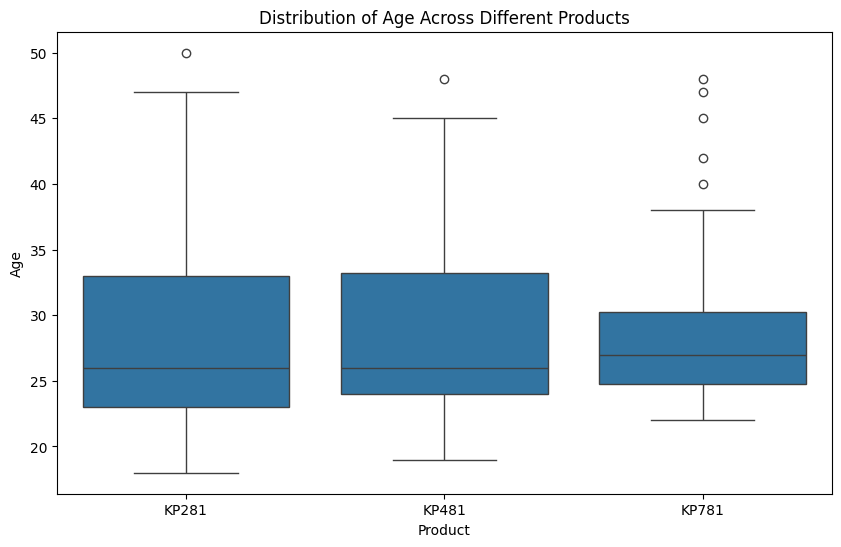

In [112]:
plt.figure(figsize = (10, 6))
sns.boxplot(data = data, x = 'Product', y = 'Age')
plt.title('Distribution of Age Across Different Products')
plt.xlabel('Product')
plt.ylabel('Age')
plt.show()

The boxplot analysis shows that the majority of customers for both the KP281 and KP481 treadmill models fall within the age range of 23 to 33 years. The KP781 model exhibits a slightly tighter distribution, with the bulk of its customer base aged between 24 and 30 years. All three models feature age outliers, with the KP781 model displaying the highest frequency or range of these unusual data points.

##Missing Value & Outlier check

### **Missing Values**

There are no null values in the data.

In [113]:
data.isna().sum()

,0
Product,0
Age,0
Gender,0
Education,0
MaritalStatus,0
Usage,0
Fitness,0
Income,0
Miles,0


### **Outliers**

The analysis identifies a total of seven age outliers across the three treadmill models. Specifically, the KP281 and KP481 models each registered one outlier, while the KP781 model accounted for the remaining five age outliers among its customers. All the outliers are upper bound outliers.

In [114]:
Q1 = data.groupby('Product', observed = False)['Age'].quantile(0.25).reset_index(name = 'Age')
Q3 = data.groupby('Product', observed = False)['Age'].quantile(0.75).reset_index(name = 'Age')

merged = Q3.merge(Q1, on = 'Product', how = 'inner')
merged['age_iqr'] = merged['Age_x'] - merged['Age_y']
merged.rename(columns = {'Age_x' : 'Q3', 'Age_y': 'Q1'}, inplace = True)
merged['lower_bound'] = merged['Q1'] - 1.5* merged['age_iqr']
merged['upper_bound'] = merged['Q3'] + 1.5* merged['age_iqr']

valid = data.merge(merged, on = 'Product', how = 'inner')
outliers = valid[(valid['Age'] < valid['lower_bound']) | (valid['Age'] > valid['upper_bound'])]
age_outliers = outliers[['Product', 'Age', 'lower_bound', 'upper_bound']]
age_outliers

,Product,Age,lower_bound,upper_bound
79,KP281,50,8.000,48.000
139,KP481,48,10.125,47.125
175,KP781,40,16.500,38.500
176,KP781,42,16.500,38.500
177,KP781,45,16.500,38.500
178,KP781,47,16.500,38.500
179,KP781,48,16.500,38.500


## Business Insights

*   Younger individuals and customers with lower annual incomes account for a disproportionately higher volume of treadmill sales. This observation suggests that age and income may be linked, as annual income often increases proportionally with professional experience and age.

*   The KP281 basic model generates the highest sales volume compared to the other two models. Furthermore, married individuals contribute significantly more to overall revenue across all models. This higher purchasing volume is likely driven by household cost-efficiency planning, as a home treadmill may be viewed as a shared, long-term alternative to multiple gym memberships.

*   The KP281 and KP481 models attract a wider age range of customers compared to the more premium KP781 model, which targets a narrower, more specific demographic.





### Recommendations

*   While focusing on making the KP281 and KP481 models highly accessible to younger and lower-income buyers by flexible financing, the company must simultaneously launch targeted marketing campaigns aimed at attracting middle-aged and older demographics, especially those with higher annual incomes, by highlighting value relevant to their needs and preferences.

*   Capitalize on the strong demand for the basic KP281 model and the high purchasing volume from married couples. Concurrently, develop robust loyalty programs designed to incentivize these high-volume owners to eventually upgrade to premium models. To grow the overall customer base, actively attract unmarried customers through focused advertising campaigns on social media and in key metropolitan areas.

*  Conduct a thorough root cause analysis to understand the factors contributing to the lower sales volume of the premium KP781 model. If the analysis points to insufficient features, prioritize the incorporation of advanced options. If price sensitivity is the primary issue, develop alternative pricing or value-driven strategies to enhance market competitiveness.


### **2. How does Fitness Level influence product choice and expected usage?**

## Non-Graphical Analysis

In [115]:
# Mean values of Usage, Miles and Income for every Fitness levels

fitness_level_mean =  data.groupby('Fitness')[['Usage', 'Miles', 'Income']].mean()
fitness_level_mean.reset_index(inplace = True)
fitness_level_mean

,Fitness,Usage,Miles,Income
0,1,2.500000,34.000000,51939.000000
1,2,2.538462,51.692308,46179.692308
2,3,3.164948,87.185567,48853.494845
3,4,3.916667,131.625000,54995.291667
4,5,4.838710,178.935484,74396.709677


In [116]:
# Number of times customers are using treadmills by their fitness level

usage_per_fitness = data.groupby(['Fitness', 'Usage'])['Product'].count()
usage_per_fitness = usage_per_fitness.reset_index()
usage_per_fitness.rename(columns = {'Fitness': 'Fitness_level', 'Usage': 'Usage_per_week', 'Product': 'Count'}, inplace = True)
usage_per_fitness

,Fitness_level,Usage_per_week,Count
0,1,2,1
1,1,3,1
2,2,2,14
3,2,3,10
4,2,4,2
5,3,2,18
6,3,3,47
7,3,4,30
8,3,5,2
9,4,3,10


In [117]:
# Number of customers for each product by fitness level

product_usage_per_fitness = data.groupby(['Fitness', 'Product'], observed = False)['Age'].count()
product_usage_per_fitness = product_usage_per_fitness.reset_index()
product_usage_per_fitness.rename(columns = {'Fitness': 'Fitness_level', 'Age': 'Count'}, inplace = True)
product_usage_per_fitness

,Fitness_level,Product,Count
0,1,KP281,1
1,1,KP481,1
2,1,KP781,0
3,2,KP281,14
4,2,KP481,12
5,2,KP781,0
6,3,KP281,54
7,3,KP481,39
8,3,KP781,4
9,4,KP281,9


## Visual Analysis

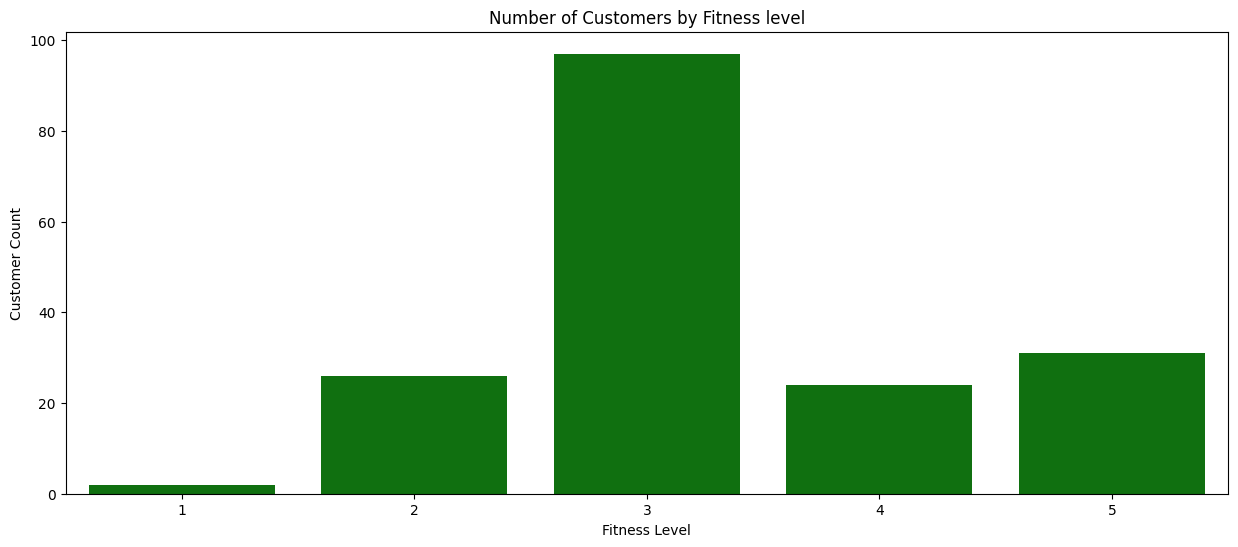

In [118]:
plt.figure(figsize = (15, 6))
sns.countplot(data = data, x = 'Fitness', color = 'green')
plt.title('Number of Customers by Fitness level')
plt.xlabel('Fitness Level')
plt.ylabel('Customer Count')
plt.show()

The countplot demonstrates a clear dominance in sales from customers reporting Fitness Level 3, who purchased over 90 treadmills. Customers categorized in Fitness Levels 2, 4, and 5 showed similar purchasing volumes, each accounting for approximately 25 to 30 treadmill sales. Conversely, customers with the weakest fitness level (Level 1) contributed minimally to sales, purchasing only two treadmills overall.

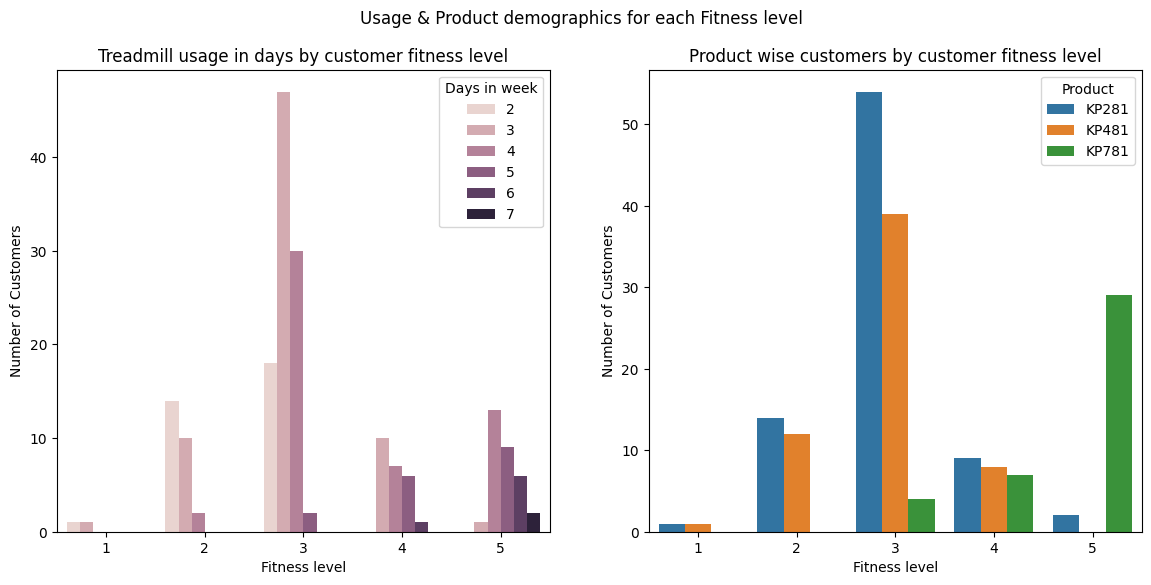

In [119]:
plt.figure(figsize = (14, 6))
plt.subplot(1, 2, 1)
sns.barplot(data = usage_per_fitness, x = 'Fitness_level', y = 'Count', hue = 'Usage_per_week')
plt.title('Treadmill usage in days by customer fitness level')
plt.xlabel('Fitness level')
plt.ylabel('Number of Customers')
plt.legend(title = 'Days in week')
plt.subplot(1, 2, 2)
sns.barplot(data = product_usage_per_fitness, x = 'Fitness_level', y = 'Count', hue = 'Product')
plt.title('Product wise customers by customer fitness level')
plt.xlabel('Fitness level')
plt.ylabel('Number of Customers')
plt.suptitle('Usage & Product demographics for each Fitness level')
plt.show()

The bar plots indicate that the majority of customers plan to use their treadmill 3 to 5 days per week. Customers reporting higher fitness levels show a tendency toward more frequent use, specifically 6 to 7 days per week. Conversely, customers with lower fitness levels generally plan for less frequent use, around 2 to 3 days per week. The KP281 model stands out as the most popular treadmill, consistently dominating sales across all customer fitness levels. The advanced KP781 model is primarily purchased by customers within the mid-to-higher fitness range.

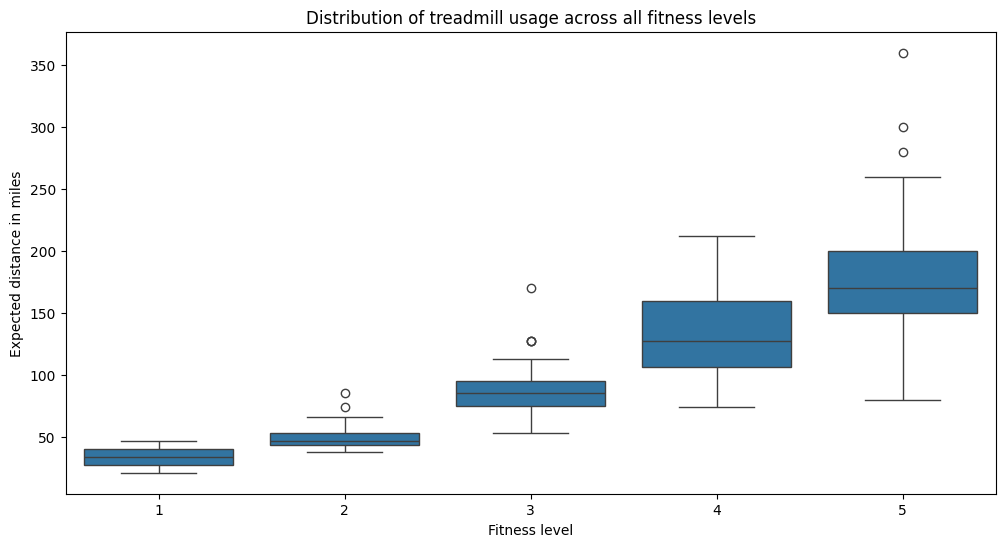

In [121]:
plt.figure(figsize = (12, 6))
sns.boxplot(data = data, x = 'Fitness', y = 'Miles')
plt.title('Distribution of treadmill usage across all fitness levels')
plt.xlabel('Fitness level')
plt.ylabel('Expected distance in miles')
plt.show()

The bar plot indicates a clear correlation between customer fitness level and expected weekly mileage. Customers with low-to-mid fitness levels anticipate a lower weekly distance, typically ranging between 25 and 40 miles. Conversely, customers reporting higher fitness levels expect extensive use, with a much wider range between 150 and 200 miles per week. The presence of outliers in Levels 2, 3, and 5 highlights the existence of a small cohort of exceptionally extensive users within those segments.

##Missing Value & Outlier check

### **Missing Values**

There are no null values in this data.

In [122]:
data.isna().sum()

,0
Product,0
Age,0
Gender,0
Education,0
MaritalStatus,0
Usage,0
Fitness,0
Income,0
Miles,0


### **Outliers**

Analysis of the expected weekly mileage reveals outliers in Fitness Levels 2, 3, and 5. Specifically, Level 3 has the highest number of outliers (four), followed by Level 5 (three outliers), and Level 2 (two outliers). Since all these are upper-bound outliers, it strongly indicates that a segment of customers in these groups plans for exceptionally extensive treadmill usage compared to their peers.

In [123]:
Q1 = data.groupby('Fitness')['Miles'].quantile(0.25).reset_index()
Q3 = data.groupby('Fitness')['Miles'].quantile(0.75).reset_index()

merged = Q3.merge(Q1, on = 'Fitness', how = 'inner')
merged.rename(columns = {'Miles_x': 'Q3', 'Miles_y': 'Q1'}, inplace = True)
merged['miles_iqr'] = merged['Q3'] - merged['Q1']
merged['lower_bound'] = merged['Q1'] - 1.5 * merged['miles_iqr']
merged['upper_bound'] = merged['Q3'] + 1.5 * merged['miles_iqr']

comb = data.merge(merged, on = 'Fitness', how = 'inner')
outliers = comb[(comb['Miles'] < comb['lower_bound']) | (comb['Miles'] > comb['upper_bound'])]
outliers = outliers[['Fitness', 'Miles', 'lower_bound', 'upper_bound']].sort_values('Fitness')
outliers

,Fitness,Miles,lower_bound,upper_bound
91,2,74,28.625,67.625
94,2,85,28.625,67.625
90,3,127,45.000,125.000
103,3,170,45.000,125.000
107,3,127,45.000,125.000
118,3,127,45.000,125.000
166,5,300,75.000,275.000
167,5,280,75.000,275.000
173,5,360,75.000,275.000


## Probability / Contingency

In [20]:
# Condidtional Probability of each product given for each level of fitness

pd.crosstab(data['Fitness'], data['Product'], normalize = 'index')

Product,KP281,KP481,KP781
Fitness,,,
1,0.500000,0.500000,0.000000
2,0.538462,0.461538,0.000000
3,0.556701,0.402062,0.041237
4,0.375000,0.333333,0.291667
5,0.064516,0.000000,0.935484


In [21]:
# Marginal probability for each fitness level

mar_prob = data['Fitness'].value_counts(normalize = True)
mar_prob.reset_index()

,Fitness,proportion
0,3,0.538889
1,5,0.172222
2,2,0.144444
3,4,0.133333
4,1,0.011111


## Business Insights

*   Customers with average fitness levels are the primary contributors to treadmill sales, while those with higher fitness levels also make a decent contribution. Conversely, customers categorized with lower fitness levels are not actively purchasing treadmills. This trend suggests that individuals who already possess a higher degree of fitness are inherently more motivated.

*   The KP281 model is the most dominant product among the three treadmill types. In contrast, the premium KP781 model is exclusively purchased by customers within the higher fitness levels. Furthermore, the majority of customers plan to use their treadmill 4 to 5 days per week. This overall purchasing and usage pattern suggests that customers favor the KP281 model and aim for a moderate and sustainable weekly workout frequency.

*   Customers categorized by lower fitness levels anticipate using the treadmill for only very short weekly distances. Conversely, those with high fitness levels plan for significantly greater mileage. This disparity suggests a direct relationship between current fitness status and workout ambition but implies that the low-fitness segment may lack the strong initial motivation observed in fitter buyers.





## Recommendations

*   The low-fitness customer segment currently represents an area of underperformance in sales compared to other groups. To stimulate growth in this area, implement a new acquisition program that offers incentives, such as complimentary, time-limited access to recorded instructional fitness videos or personal training sessions, specifically designed to lower the barrier to entry and increase motivation for this demographic.

*   Capitalize on the high market demand for the KP281 model and offer a trade-in program where customers could receive a discount on an advanced model (KP481 or KP781) when trading in their older treadmills. The collected used treadmills can then be refurbished and resold, which offers a dual benefit: increasing sales of the higher-tier models and generating secondary revenue from the refurbished market.

*   Launch a comprehensive advertisement campaign focused on raising awareness about the benefits of daily running or jogging, emphasizing the unique advantages of working out within one's own home space. This strategic messaging will aim to specifically motivate busy individuals, such as employees and late-shift workers, thereby driving overall sales volume across the product line.





###**3.How does Income affect product choice, usage intensity, and upgrade potential?**

### Non-Graphical Analysis

In [124]:
data['Income'].describe()

,Income
count,180.000000
mean,53719.577778
std,16506.684226
min,29562.000000
25%,44058.750000
50%,50596.500000
75%,58668.000000
max,104581.000000


In [125]:
# Income Categorization

data['Income_cat'] = pd.cut(data['Income'], bins = [25000, 45000, 65000, 85000, 106000], labels = ['Low', 'Mid', 'High', 'Very High'])
data.head()

,Product,Age,Gender,Education,MaritalStatus,Usage,Fitness,Income,Miles,Income_cat
0,KP281,18,Male,14,Single,3,4,29562,112,Low
1,KP281,19,Male,15,Single,2,3,31836,75,Low
2,KP281,19,Female,14,Partnered,4,3,30699,66,Low
3,KP281,19,Male,12,Single,3,3,32973,85,Low
4,KP281,20,Male,13,Partnered,4,2,35247,47,Low


In [126]:
# Customers by Income category

cat_wise_cust = data.groupby('Income_cat', observed = False)['Income'].count().reset_index()
cat_wise_cust.rename(columns = {'Income': 'Customer_count'}, inplace = True)
cat_wise_cust

,Income_cat,Customer_count
0,Low,49
1,Mid,103
2,High,11
3,Very High,17


In [127]:
# Number of customers in each Income category by product

grouped = data.groupby(['Income_cat', 'Product'], observed = False)['Usage'].count().reset_index()
grouped.rename(columns = {'Usage': 'Customer_count'}, inplace = True)
grouped

,Income_cat,Product,Customer_count
0,Low,KP281,34
1,Low,KP481,15
2,Low,KP781,0
3,Mid,KP281,44
4,Mid,KP481,43
5,Mid,KP781,16
6,High,KP281,2
7,High,KP481,2
8,High,KP781,7
9,Very High,KP281,0


In [128]:
# Customers estimated usage in each Income category

cat_usage = data.groupby(['Income_cat', 'Usage'], observed = False)['Age'].count().reset_index()
cat_usage.rename(columns = {'Age': 'Customer_count'}, inplace = True)
cat_usage

,Income_cat,Usage,Customer_count
0,Low,2,9
1,Low,3,27
2,Low,4,10
3,Low,5,3
4,Low,6,0
5,Low,7,0
6,Mid,2,23
7,Mid,3,39
8,Mid,4,33
9,Mid,5,8


## Visual Analysis

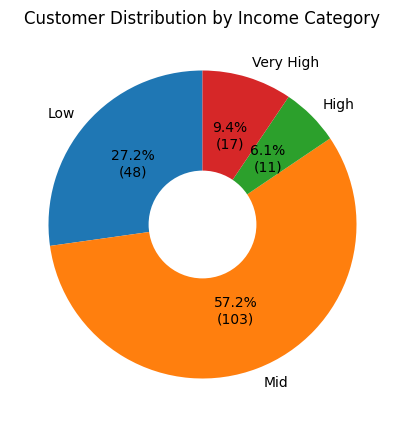

In [129]:
fig, ax = plt.subplots(figsize=(5, 5))
pie_values = cat_wise_cust['Customer_count']
labels = cat_wise_cust['Income_cat']
ax.pie(pie_values, labels=labels, autopct=lambda pct: f"{pct:.1f}%\n({int(pct/100 * pie_values.sum())})", startangle=90)
centre_circle = plt.Circle((0,0), 0.35, fc='white')
fig.gca().add_artist(centre_circle)
ax.set_title('Customer Distribution by Income Category')
plt.show()

The pie chart illustrates that the Mid-Income Group dominates purchases, accounting for a substantial 57.2% market share, corresponding to 103 units sold. The Low-Income Group represents the second-largest segment, capturing 27.2% of the market with 48 purchases. Collectively, the Very High and High Income Groups account for a significantly smaller portion of total sales, purchasing only 17 and 11 treadmills, respectively, representing 9.4% and 6.1% of the entries.

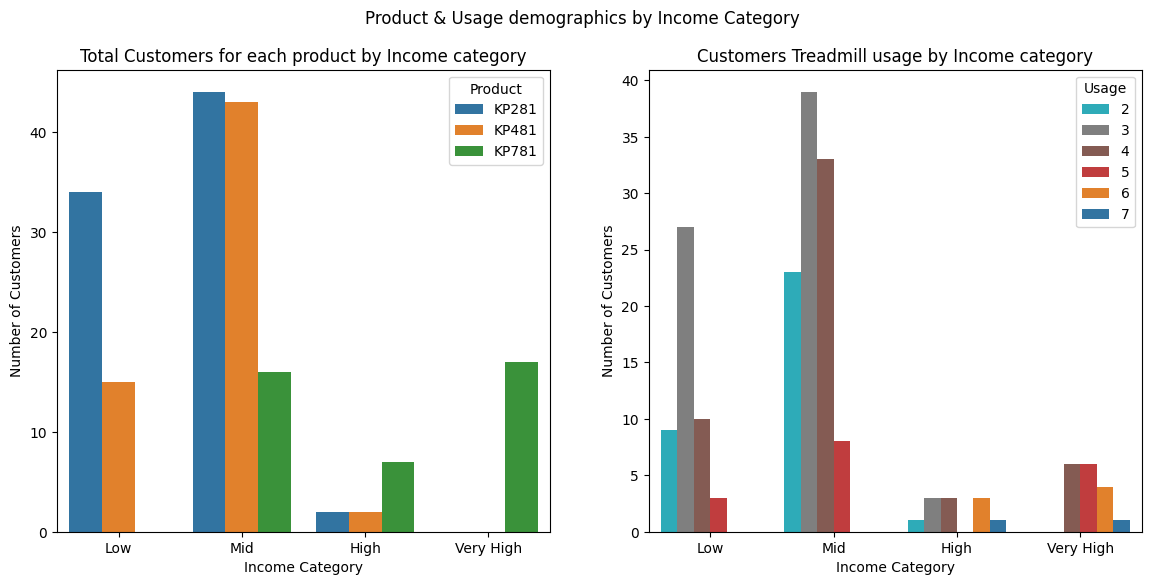

In [134]:
plt.figure(figsize = (14, 6))
plt.subplot(1, 2, 1)
sns.barplot(grouped, x = 'Income_cat', y = 'Customer_count', hue = 'Product')
plt.title('Total Customers for each product by Income category')
plt.xlabel('Income Category')
plt.ylabel('Number of Customers')
plt.subplot(1, 2, 2)
sns.barplot(cat_usage, x = 'Income_cat', y = 'Customer_count', hue = 'Usage', palette = 'tab10_r')
plt.title('Customers Treadmill usage by Income category')
plt.xlabel('Income Category')
plt.ylabel('Number of Customers')
plt.suptitle('Product & Usage demographics by Income Category')
plt.show()

The first bar chart demonstrates that the KP281 model is the preferred product among customers in both the Low and Mid income categories. Conversely, the advanced KP781 model dominates sales within the High and Very High income groups, with Very High income customers purchasing only the KP781 model. While the second bar chart confirms that Low and Mid income customers are numerically greater, it reveals that individuals in the High and Very High income groups plan to use the treadmill significantly more often.

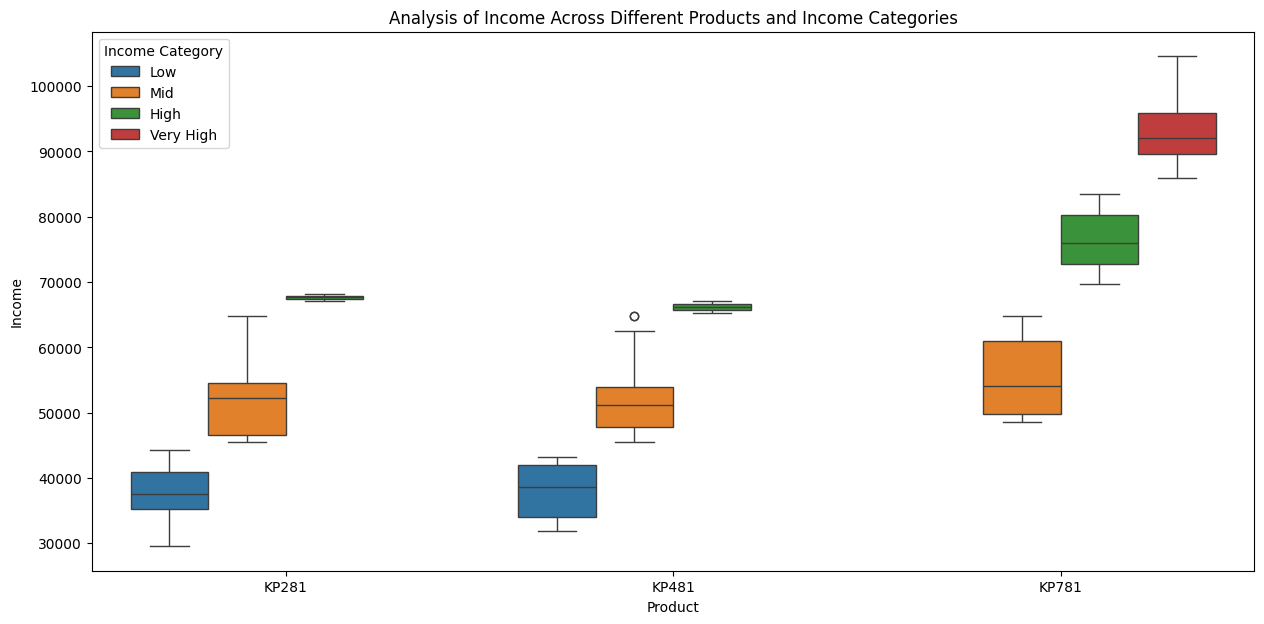

In [135]:
plt.figure(figsize = (15, 7))
sns.boxplot(data, x = 'Product', y = 'Income', hue = 'Income_cat')
plt.title('Analysis of Income Across Different Products and Income Categories')
plt.legend(title = 'Income Category')
plt.show()

The box chart indicates that the KP281 and KP481 models are primarily purchased by Low and Mid income customers, with the High income category contributing a negligible portion of sales. Notably, the Very High income group showed no interest in either of these two models. Conversely, sales of the KP781 model are exclusively driven by Mid, High, and Very High income customers, with the Low income group making no purchases of this premium model. Furthermore, the data reveals potential outliers within the Mid income customer group for the KP481 model.

## Missing Value & Outlier Check

### **Missing Values**
There are no null values in this data.

In [20]:
data.isnull().sum()

,0
Product,0
Age,0
Gender,0
Education,0
MaritalStatus,0
Usage,0
Fitness,0
Income,0
Miles,0
Income_cat,0


### **Outliers**
Analysis reveals outliers as Mid income category customers for "KP481" model. Since all these are upper-bound outliers, it strongly indicates that a segment of customers in these groups plans for exceptionally extensive treadmill usage compared to their peers.

In [51]:
Q1 = data.groupby(['Product', 'Income_cat'], observed = False)['Income'].quantile(0.25).reset_index()
Q3 = data.groupby(['Product', 'Income_cat'], observed = False)['Income'].quantile(0.75).reset_index()
Q1.fillna({'Income': 0}, inplace = True)
Q3.fillna({'Income': 0}, inplace = True)

merged = Q3.merge(Q1, on = ('Product', 'Income_cat'), how = 'inner')
merged.rename(columns = {'Income_x': 'Q3', 'Income_y': 'Q1'}, inplace = True)
merged['iqr'] = merged['Q3'] - merged['Q1']
merged['lower_bound'] = merged['Q1'] - 1.5 * merged['iqr']
merged['upper_bound'] = merged['Q3'] + 1.5 * merged['iqr']

comb = data.merge(merged, on = ('Product', 'Income_cat'), how = 'inner')
outliers = comb[(comb['Income'] < comb['lower_bound']) | (comb['Income'] > comb['upper_bound'])]
outliers = outliers[['Product', 'Income_cat', 'Income', 'lower_bound', 'upper_bound']]
outliers

,Product,Income_cat,Income,lower_bound,upper_bound
125,KP481,Mid,64809,38373.75,63387.75
137,KP481,Mid,64809,38373.75,63387.75


## Probability / Contingency

In [52]:
# Conditional Probability for each Product given at every income category

pd.crosstab(data['Income_cat'], data['Product'], normalize = 'index')

Product,KP281,KP481,KP781
Income_cat,,,
Low,0.693878,0.306122,0.000000
Mid,0.427184,0.417476,0.155340
High,0.181818,0.181818,0.636364
Very High,0.000000,0.000000,1.000000


In [63]:
# Marginal probability for product at each Income category

mar_prob = pd.crosstab(data['Income_cat'], data['Product'], normalize = True)
mar_prob

Product,KP281,KP481,KP781
Income_cat,,,
Low,0.188889,0.083333,0.000000
Mid,0.244444,0.238889,0.088889
High,0.011111,0.011111,0.038889
Very High,0.000000,0.000000,0.094444


## Business Insights

*   Customers in the Mid and Low income groups constitute the vast majority of the customer base, contributing over 85% of total sales volume. This observation clearly indicates that the higher income demographic represents an underdeveloped market segment and presents a significant, untapped opportunity for targeted acquisition strategies.

*   There is a sharp divergence in product preference based on income. Customers in the Low income group show no interest in acquiring the advanced "KP781" model, while the Very High income group is exclusively interested in purchasing the "KP781" model. This highlights an opportunity loss, as some customers within the High income group are still opting for basic models despite their financial capacity for premium options.





## Recommendations

*   Launch a highly targeted, exclusive marketing campaign that emphasizes the advanced technology, durability, and high performance of the KP781. This campaign should clearly differentiate the KP781 as an exclusive status and performance tool, not just a basic piece of home equipment. Implement a mandatory consultation or specialized purchasing channel for the KP781 to enhance the sense of premium experience and better guide High Income buyers away from entry-level models.

*   Introduce flexible financing options exclusively for the KP781 model like 0% APR for initial 12 or 24 months for customers with specific credit profiles. Since the Low-Income group is not buying the KP781, offer an incentivized upgrade path from the KP481 model to the KP781 for Mid-Income customers, framing it as an affordable transition to "professional-grade" equipment after a certain period of KP481 ownership.



### **4. Are there gender-based differences in product selection, usage, and fitness?**

## Non-Graphical Analysis

In [136]:
# Gender wise Product count

prod_count_by_gender = data.groupby(['Gender', 'Product'], observed = False).size().reset_index(name = 'Customer_count')
prod_count_by_gender

,Gender,Product,Customer_count
0,Female,KP281,40
1,Female,KP481,29
2,Female,KP781,7
3,Male,KP281,40
4,Male,KP481,31
5,Male,KP781,33


In [137]:
# Gender wise Weekly usage estimation

usage_estim_by_gender = pd.crosstab(data['Gender'], data['Usage'])
usage_estim_by_gender

Usage,2,3,4,5,6,7
Gender,,,,,,
Female,20,33,14,7,2,0
Male,13,36,38,10,5,2


In [138]:
# Gender wise fitness levels

fitness_levels_by_gender = data.groupby(['Gender', 'Fitness'], observed = False).size().reset_index(name = 'Customer_count')
fitness_levels_by_gender

,Gender,Fitness,Customer_count
0,Female,1,1
1,Female,2,16
2,Female,3,45
3,Female,4,8
4,Female,5,6
5,Male,1,1
6,Male,2,10
7,Male,3,52
8,Male,4,16
9,Male,5,25


## Visual Analysis

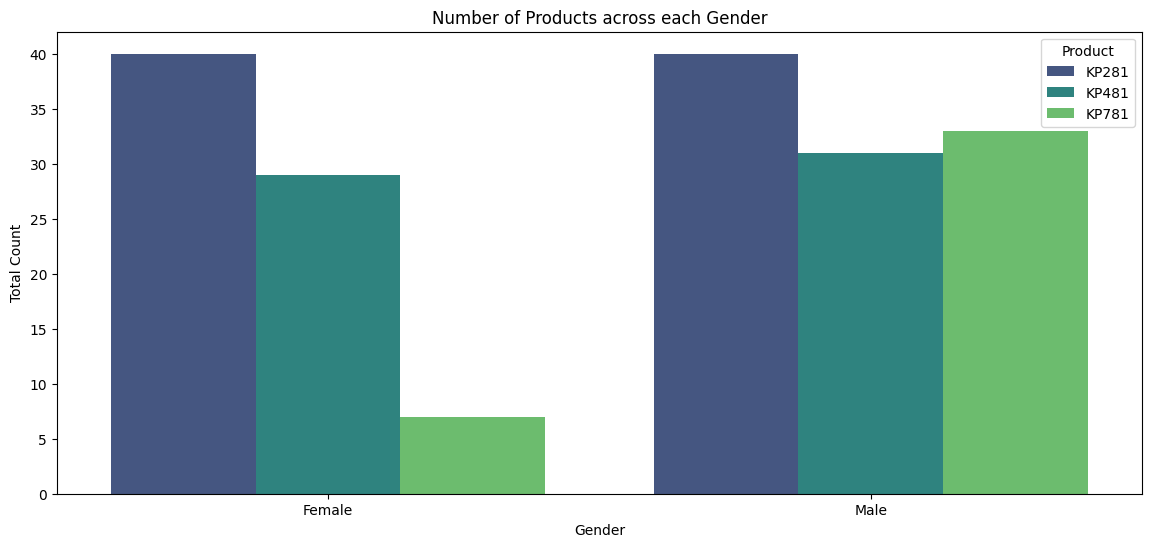

In [149]:
plt.figure(figsize = (14, 6))
sns.barplot(data = prod_count_by_gender, x = 'Gender', y = 'Customer_count', hue = 'Product', palette = 'viridis')
plt.title('Number of Products across each Gender')
plt.ylabel('Total Count')
plt.show()

The bar chart illustrates that female customers overwhelmingly favor the 'KP281' model, which represents more than half of their total purchases (40 units), followed by 29 'KP481' units and only 7 'KP781' units. For men, while the KP281 model also leads sales, their spending is more evenly distributed across the premium models, with the KP481 and KP781 accounting for 31 and 33 units, respectively.

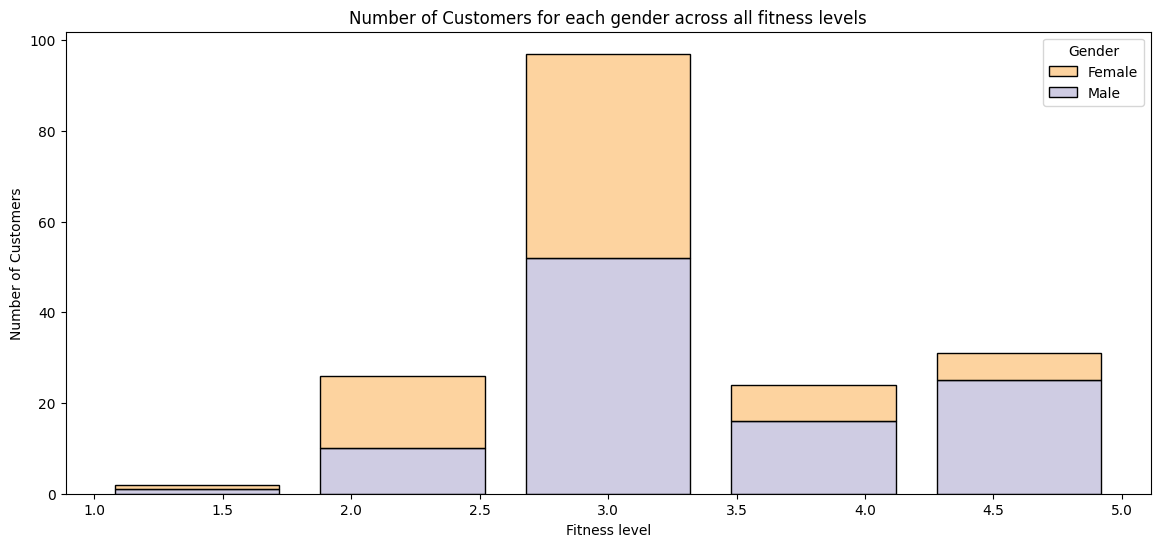

In [148]:
plt.figure(figsize = (14, 6))
sns.histplot(data = fitness_levels_by_gender, x = 'Fitness', hue = 'Gender', weights = 'Customer_count', bins = 5, multiple = 'stack', shrink = 0.8, palette = 'PuOr')
plt.title('Number of Customers for each gender across all fitness levels')
plt.xlabel('Fitness level')
plt.ylabel('Number of Customers')
plt.show()

The stacked bar chart illustrates distinct patterns in customer purchasing based on gender and fitness level. In the lower fitness categories (Levels 1, 2, and 3), the number of women customers is nearly equal to that of men, with women even exceeding men in Level 2. Conversely, moving into the mid-to-high fitness levels (Levels 3, 4, and 5), men become clearly dominant, showing a substantial lead over women customers.

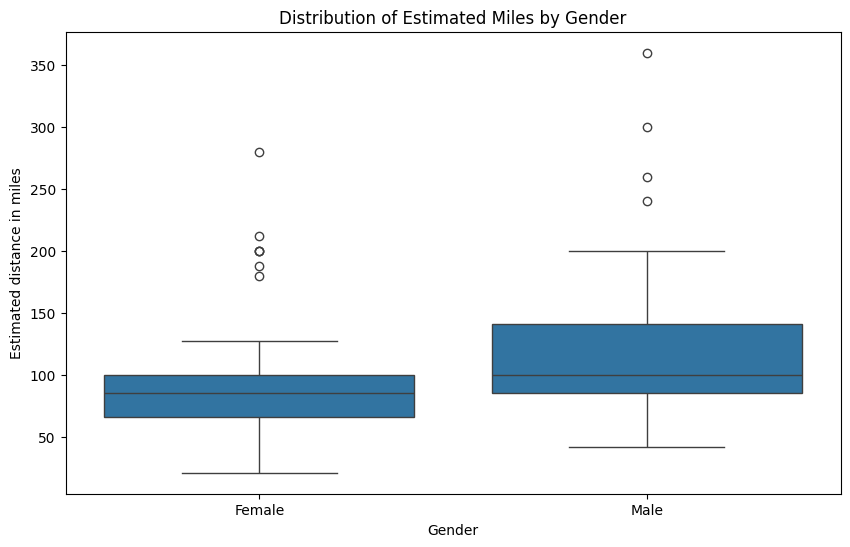

In [150]:
plt.figure(figsize = (10, 6))
sns.boxplot(data = data, x = 'Gender', y = 'Miles')
plt.title('Distribution of Estimated Miles by Gender')
plt.ylabel('Estimated distance in miles')
plt.show()

The box chart illustrates that female customers typically use treadmills for shorter weekly distances compared to men, showing a smaller central range between 60 and 100 miles. In contrast, male customers substantially utilize the treadmills more, exhibiting a wider range of usage that spans from approximately 75 to 140 miles weekly. Both genders feature upper-bound outliers indicating the presence of a few exceptionally extensive users within each group.

## Missing Values & Outliers

### **Missing Values**
There are no missing values in this data.

In [101]:
data.isnull().sum()

,0
Product,0
Age,0
Gender,0
Education,0
MaritalStatus,0
Usage,0
Fitness,0
Income,0
Miles,0


### **Outliers**

Analysis reveals outliers for both Male and Female customers. Since all these are upper-bound outliers, it strongly indicates that a segment of customers plans to treadmill usage compared to their peers.

In [136]:
Q1 = data.groupby('Gender', observed = False)['Miles'].quantile(0.25).reset_index(name = 'Q1')
Q3 = data.groupby('Gender', observed = False)['Miles'].quantile(0.75).reset_index(name = 'Q3')

merged = Q3.merge(Q1, on = 'Gender', how = 'inner')
merged['IQR'] = merged['Q3'] - merged['Q1']
merged['lower_bound'] = merged['Q1'] - 1.5 * merged['IQR']
merged['upper_bound'] = merged['Q3'] + 1.5 * merged['IQR']

comb = data.merge(merged, on = 'Gender', how = 'inner')
outliers = comb[(comb['Miles'] < comb['lower_bound']) | (comb['Miles'] > comb['upper_bound'])]
outliers = outliers[['Gender', 'Miles', 'lower_bound', 'upper_bound']]
outliers

,Gender,Miles,lower_bound,upper_bound
23,Female,188,15.0,151.0
84,Female,212,15.0,151.0
148,Female,200,15.0,151.0
152,Female,200,15.0,151.0
155,Male,240,1.0,225.0
162,Female,180,15.0,151.0
166,Male,300,1.0,225.0
167,Female,280,15.0,151.0
170,Male,260,1.0,225.0
171,Female,200,15.0,151.0


## Probability / Contingency

In [137]:
# Conditional Probability for each Product given for all genders

cond_prob = pd.crosstab(data['Gender'], data['Product'], normalize = 'index')
cond_prob

Product,KP281,KP481,KP781
Gender,,,
Female,0.526316,0.381579,0.092105
Male,0.384615,0.298077,0.317308


In [139]:
# Marginal Probability of each Product for all genders

mar_prob = pd.crosstab(data['Product'], data['Gender'], normalize = True)
mar_prob

Gender,Female,Male
Product,,
KP281,0.222222,0.222222
KP481,0.161111,0.172222
KP781,0.038889,0.183333


## Business Insights

*   Male customers purchased the three treadmill models almost evenly, distributing their buying power across the entire product line. In contrast, female customers invested most heavily in the basic "KP281" model, with very few purchases of the advanced "KP781" model. This clear preference and low penetration into the premium segment indicate a significant untapped market opportunity within the female customer base for the KP781 model.

*   The data indicates that female customers are more numerous and dominate the lower fitness levels compared to male customers. Conversely, male customers exhibit a greater presence within the higher fitness levels. The mid-range fitness level (Level 3), however, shows a nearly equal distribution of male and female customers.



## Recommendations

*   Launch a targeted campaign featuring female role models at varying fitness levels using the KP781. The messaging should emphasize features crucial for beginners/rehabilitation, safety and stability, goal-tracking and progressive programs and Comfort and specialized features.

*   Develop an exclusive "Premium Starter Bundle" for the KP781 that is marketed heavily to female customers. This bundle should include high-value add-ons relevant to women. Crucially, pair this with flexible, competitive financing options to address the high initial cost, which is a key for customers currently opting for the basic KP281 model.



### **5. How does Usage frequency & Miles pattern relate to product type?**

## Non-Graphical Analysis

In [152]:
# Miles Categorization

bins = [15, 50, 125, 200, 250, 380]
labels = ['Low', 'Moderate', 'High', 'Very High', 'Extreme']

data['Distance_cat'] = pd.cut(data['Miles'], bins = bins, labels = labels)
data.head()

,Product,Age,Gender,Education,MaritalStatus,Usage,Fitness,Income,Miles,Income_cat,Distance_cat
0,KP281,18,Male,14,Single,3,4,29562,112,Low,Moderate
1,KP281,19,Male,15,Single,2,3,31836,75,Low,Moderate
2,KP281,19,Female,14,Partnered,4,3,30699,66,Low,Moderate
3,KP281,19,Male,12,Single,3,3,32973,85,Low,Moderate
4,KP281,20,Male,13,Partnered,4,2,35247,47,Low,Low


In [153]:
# Mean values of Miles, Fitness, Income across Distance categories

means_by_dist_cat = data.groupby('Distance_cat', observed = False)[['Miles', 'Fitness', 'Income']].mean().reset_index()
means_by_dist_cat

,Distance_cat,Miles,Fitness,Income
0,Low,42.705882,1.882353,47778.176471
1,Moderate,85.363636,3.099174,49337.454545
2,High,163.000000,4.444444,67190.083333
3,Very High,226.000000,4.500000,55028.000000
4,Extreme,300.000000,5.000000,89641.000000


In [154]:
# Products within each distance category by usage

prod_usage_per_dc = data.groupby(['Distance_cat', 'Usage', 'Product'], observed = False).size().reset_index(name = 'Product_count')
prod_usage_per_dc

,Distance_cat,Usage,Product,Product_count
0,Low,2,KP281,8
1,Low,2,KP481,5
2,Low,2,KP781,0
3,Low,3,KP281,3
4,Low,3,KP481,0
...,...,...,...,...
85,Extreme,6,KP481,0
86,Extreme,6,KP781,2
87,Extreme,7,KP281,0
88,Extreme,7,KP481,0


## Visual Analysis

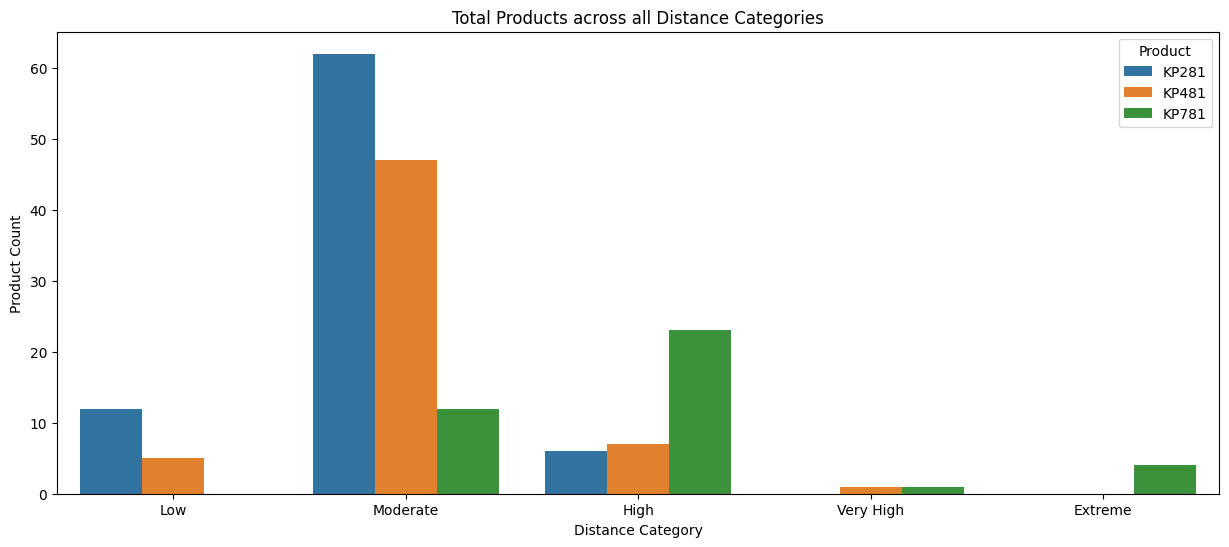

In [155]:
plt.figure(figsize = (15, 6))
sns.countplot(data = data, x = 'Distance_cat', hue = 'Product')
plt.title('Total Products across all Distance Categories')
plt.xlabel('Distance Category')
plt.ylabel('Product Count')
plt.show()

The bar graph demonstrates that the Moderate distance category of customers is the most dominant in sales volume. Only customers in the Moderate and High distance categories purchase all three types of treadmills. In contrast, the Low distance category customers invested only in the "KP281" and "KP481" models. Furthermore, customers in the Very High and Extreme distance categories consistently avoided the basic "KP281" model, concentrating their investment on the advanced treadmill models.  

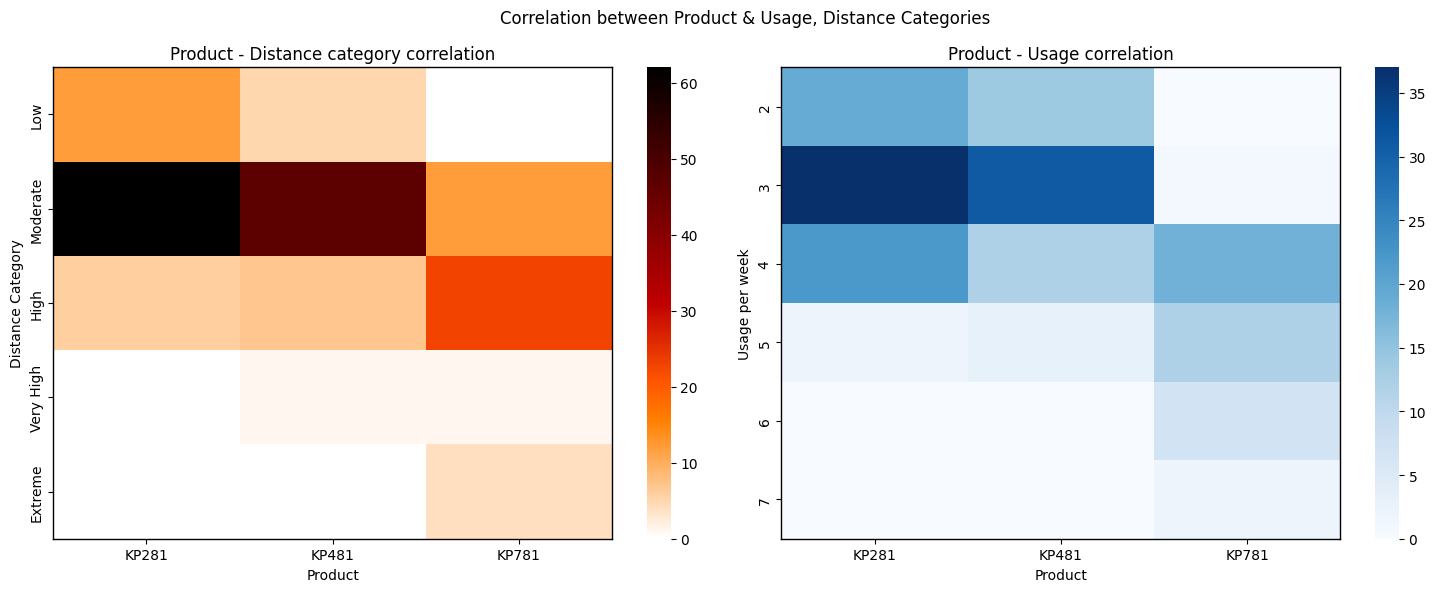

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
heat_data_1 = data.groupby(['Distance_cat', 'Product'], observed = False).size().unstack()
sns.heatmap(heat_data_1, ax=axes[0], cmap="gist_heat_r", cbar=True)
axes[0].set_title("Product - Distance category correlation")
axes[0].set_ylabel("Distance Category")
for spine in axes[0].spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1)
    spine.set_color("black")

heat_data_2 = data.groupby(['Usage', 'Product'], observed = False).size().unstack()
sns.heatmap(heat_data_2, ax=axes[1], cmap="Blues", cbar=True)
axes[1].set_title("Product - Usage correlation")
axes[1].set_ylabel("Usage per week")
for spine in axes[1].spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1)
    spine.set_color("black")
plt.suptitle('Correlation between Product & Usage, Distance Categories')
plt.tight_layout()
plt.show()

The heat maps clearly depicts that the KP281 model achieves its maximum sales volume within the Moderate distance category. In the Extreme distance category, only the premium KP781 model contributes to sales. Overall, the KP781 model accounts for sales across all usage categories except for the Low distance category. The data suggests a clear purchasing strategy: customers planning for less frequent use favor the KP281 model, while those planning for extensive, high-frequency use select the advanced KP781 model. The KP481 model serves as the ideal intermediate option between these two extremes.

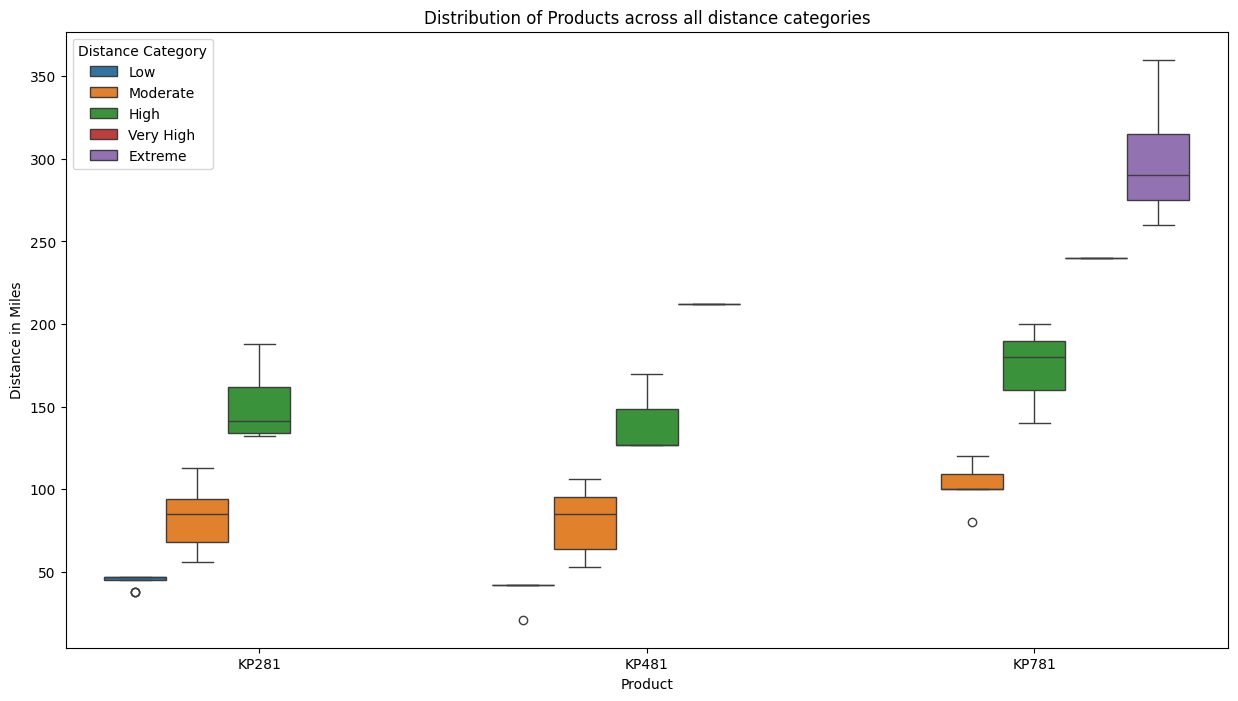

In [139]:
plt.figure(figsize = (15, 8))
sns.boxplot(data = data, x = 'Product', y = 'Miles', hue = 'Distance_cat')
plt.title('Distribution of Products across all distance categories')
plt.ylabel('Distance in Miles')
plt.legend(title = 'Distance Category')
plt.show()

The box plot illustrates the sales reach of each model by customer usage distance. The KP281 model captures sales within the Low, Moderate, and High distance categories. The KP481 model exhibits a broader reach, accounting for sales across the Low, Moderate, High, and Very High distance categories. In contrast, the KP781 model is unique in that it does not cater to the Low distance category but successfully includes the Extreme distance category along with the other middle and high usage groups. Additionally, the data shows a few outliers in certain usage distance categories.

## Missing Values & Outliers

### **Missing Values**

There are no missing values in this data.

In [47]:
data.isna().sum()

,0
Product,0
Age,0
Gender,0
Education,0
MaritalStatus,0
Usage,0
Fitness,0
Income,0
Miles,0
Distance_cat,0


### **Outliers**

Analysis of the usage distance categories reveals a total of five outliers: four are concentrated in the Low distance category, and one is found in the Moderate distance category. All three treadmill types are represented among these extreme data points. Significantly, all identified outliers are lower-bound outliers, indicating that these customers plan for weekly distances significantly below the typical expected range for their respective categories.

In [46]:
Q1 = data.groupby(['Distance_cat', 'Product'], observed = False)['Miles'].quantile(0.25).reset_index()
Q3 = data.groupby(['Distance_cat', 'Product'], observed = False)['Miles'].quantile(0.75).reset_index()
Q1.fillna({'Miles': 0}, inplace = True)
Q3.fillna({'Miles': 0}, inplace = True)

merged = Q3.merge(Q1, on = ('Distance_cat', 'Product'), how = 'inner')
merged.rename(columns = {'Miles_x': 'Q3', 'Miles_y': 'Q1'}, inplace = True)
merged['IQR'] = merged['Q3'] - merged['Q1']
merged['lower_bound'] = merged['Q1'] - 1.5 * merged['IQR']
merged['upper_bound'] = merged['Q3'] + 1.5 * merged['IQR']

comb = data.merge(merged, on = ('Distance_cat', 'Product'), how = 'inner')
outliers = comb[(comb['Miles'] < comb['lower_bound']) | (comb['Miles'] > comb['upper_bound'])]
outliers = outliers[['Distance_cat', 'Product', 'Miles', 'lower_bound', 'upper_bound']]
outliers

,Distance_cat,Product,Miles,lower_bound,upper_bound
19,Low,KP281,38,41.375,50.375
51,Low,KP281,38,41.375,50.375
59,Low,KP281,38,41.375,50.375
117,Low,KP481,21,42.000,42.000
147,Moderate,KP781,80,85.750,123.750


## Probability / Contingency

In [49]:
data.head()

,Product,Age,Gender,Education,MaritalStatus,Usage,Fitness,Income,Miles,Distance_cat
0,KP281,18,Male,14,Single,3,4,29562,112,Moderate
1,KP281,19,Male,15,Single,2,3,31836,75,Moderate
2,KP281,19,Female,14,Partnered,4,3,30699,66,Moderate
3,KP281,19,Male,12,Single,3,3,32973,85,Moderate
4,KP281,20,Male,13,Partnered,4,2,35247,47,Low


In [51]:
# Conditional Probability for each Product given for all Distance categories

cond_prob = pd.crosstab(data['Distance_cat'], data['Product'], normalize = 'index')
cond_prob

Product,KP281,KP481,KP781
Distance_cat,,,
Low,0.705882,0.294118,0.000000
Moderate,0.512397,0.388430,0.099174
High,0.166667,0.194444,0.638889
Very High,0.000000,0.500000,0.500000
Extreme,0.000000,0.000000,1.000000


In [53]:
# Marginal probability for each Distance category

mar_prob = data['Distance_cat'].value_counts(normalize = True).reset_index(name = 'Probability')
mar_prob

,Distance_cat,Probability
0,Moderate,0.672222
1,High,0.200000
2,Low,0.094444
3,Extreme,0.022222
4,Very High,0.011111


## Business Insights

*   Customer purchasing decisions are strongly segmented and directly correlated with their planned weekly usage distance. The KP281 model is positioned as the definitive choice for Low-to-Moderate frequency/distance users, as evidenced by its maximum sales volume in the Moderate category and its complete absence from the Very High and Extreme categories. Conversely, the KP781 model is strictly reserved for High-Usage customers with the Extreme category purchasing it exclusively. This confirms the models are successfully targeting distinct user needs like basic/convenience (KP281) versus high-performance/durability (KP781).

*   The KP481 model is critical for expanding the product line's reach. It is the only model purchased by Low distance users alongside the KP281 and is essential for capturing the Very High distance segment where the basic KP281 is rejected. Its ability to perform effectively across four distinct usage categories (Low, Moderate, High, and Very High) establishes it as the most versatile model, serving as the necessary bridge for customers transitioning from low-level convenience to higher-level, more sustained usage.

*   The Low distance category is entirely excluded from purchasing the premium KP781 model, indicating a strong price sensitivity or a failure to convey premium value to low-usage customers. While these users gravitate toward the affordable KP281 and KP481, there is a missed opportunity to introduce premium features focused on comfort or simplicity (rather than performance) to this segment. Any effort to upsell the KP781 must address the price barrier while avoiding reliance on high-performance metrics that are irrelevant to their low distance goals.





## Recommendations

*   Aggressively market the KP481 as the value-driven choice for the long term. Position it directly against the KP281 by emphasizing its superior durability and slightly higher capacity, making it the model that prevents the need for an early upgrade. Create a calculator on the product page showing the cost-per-mile advantage of the KP481 over the KP281 for a customer who expects to increase their usage from 3 days/week to 5 days/week within one year. This specifically targets the large Moderate distance segment.

*   Develop a targeted campaign or a software-only variant of the KP781 that focuses on non-performance premium features relevant to low-usage buyers. This could include superior noise reduction, advanced cushioning/shock absorption, for joint pain, and a simplified, guided beginner workout interface. This addresses the untapped Low Distance opportunity by justifying the premium price on comfort, safety, and ease-of-use, rather than speed and capacity.

*   Launch an exclusive "Pro-User Loyalty Program" dedicated to KP781 buyers. This program should offer tangible benefits for intensive use, such as discounted extended warranties, prioritized access to new performance software updates, and discounted parts/maintenance kits. This strategy reinforces the KP781's premium status and ensures high customer lifetime value by rewarding the most committed, heavy-usage customers, thereby securing their repeat business and word-of-mouth advocacy.

### **6. How do Education & Marital Status relate to product choice and customer lifecycle value?**

## Non-Graphical Analysis

In [14]:
# Mean values of Miles, Usage, Income across each MaritalStatus and their education

mean_values = data.groupby(['MaritalStatus','Education'], observed = False)[['Income','Usage','Miles']].mean().reset_index()
mean_values

,MaritalStatus,Education,Income,Usage,Miles
0,Partnered,12,32973.000000,2.000000,53.000000
1,Partnered,13,43585.000000,3.666667,88.000000
2,Partnered,14,45776.206897,3.137931,93.137931
3,Partnered,15,35815.500000,2.000000,61.500000
4,Partnered,16,54772.142857,3.303571,98.982143
5,Partnered,18,83638.928571,4.857143,157.500000
6,Partnered,20,74701.000000,4.000000,170.000000
7,Partnered,21,90886.000000,4.000000,100.000000
8,Single,12,38658.000000,3.500000,89.500000
9,Single,13,39795.000000,3.500000,95.500000


In [19]:
# Number of Products by Marital status across their Education qualification

prod_per_edu_marstat = data.groupby(['MaritalStatus', 'Education'], observed = False)['Product'].size().reset_index()
prod_per_edu_marstat

,MaritalStatus,Education,Product
0,Partnered,12,1
1,Partnered,13,3
2,Partnered,14,29
3,Partnered,15,2
4,Partnered,16,56
5,Partnered,18,14
6,Partnered,20,1
7,Partnered,21,1
8,Single,12,2
9,Single,13,2


## Visual Analysis

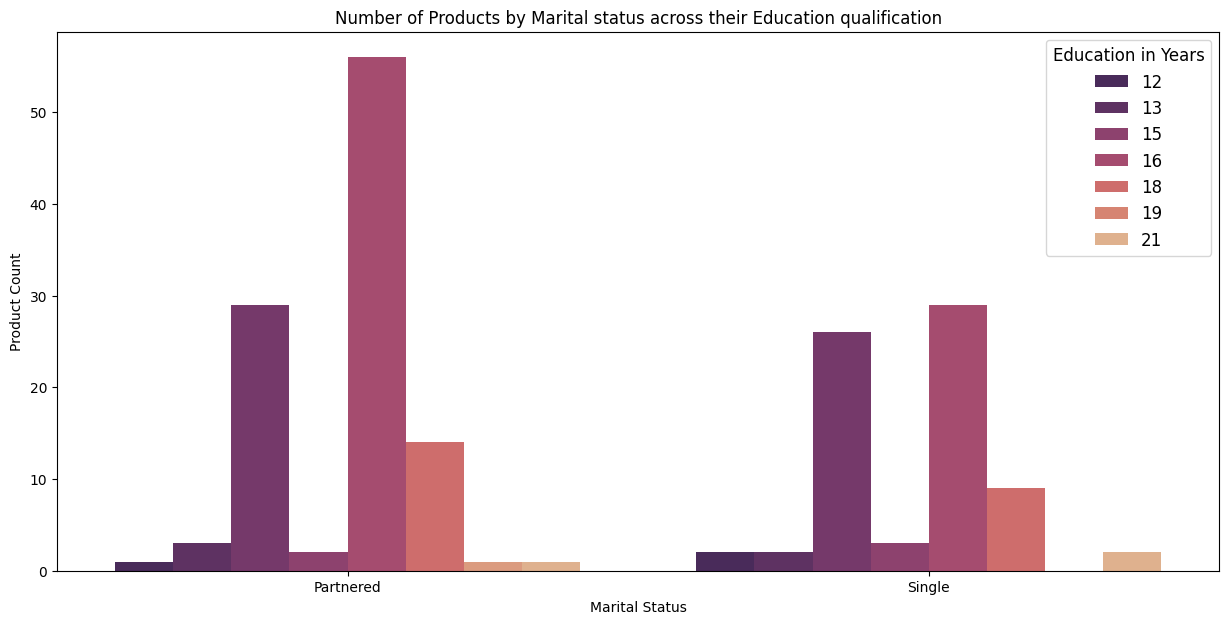

In [69]:
plt.figure(figsize = (15, 7))
sns.barplot(data = prod_per_edu_marstat, x = 'MaritalStatus', y = 'Product', hue = 'Education', palette = 'flare_r')
plt.title('Number of Products by Marital status across their Education qualification')
plt.xlabel('Marital Status')
plt.ylabel('Product Count')
plt.legend(title = 'Education in Years', fontsize = 12, title_fontsize = 12)
plt.show()

The bar charts clearly demonstrate that partnered individuals contribute significantly more to overall sales compared to single individuals. Conversely, customers with higher levels of education result in lower sales volumes than those with lesser education. Across both the partnered and single groups, customers with 16 years of education represent the leading segment in terms of purchase volume.

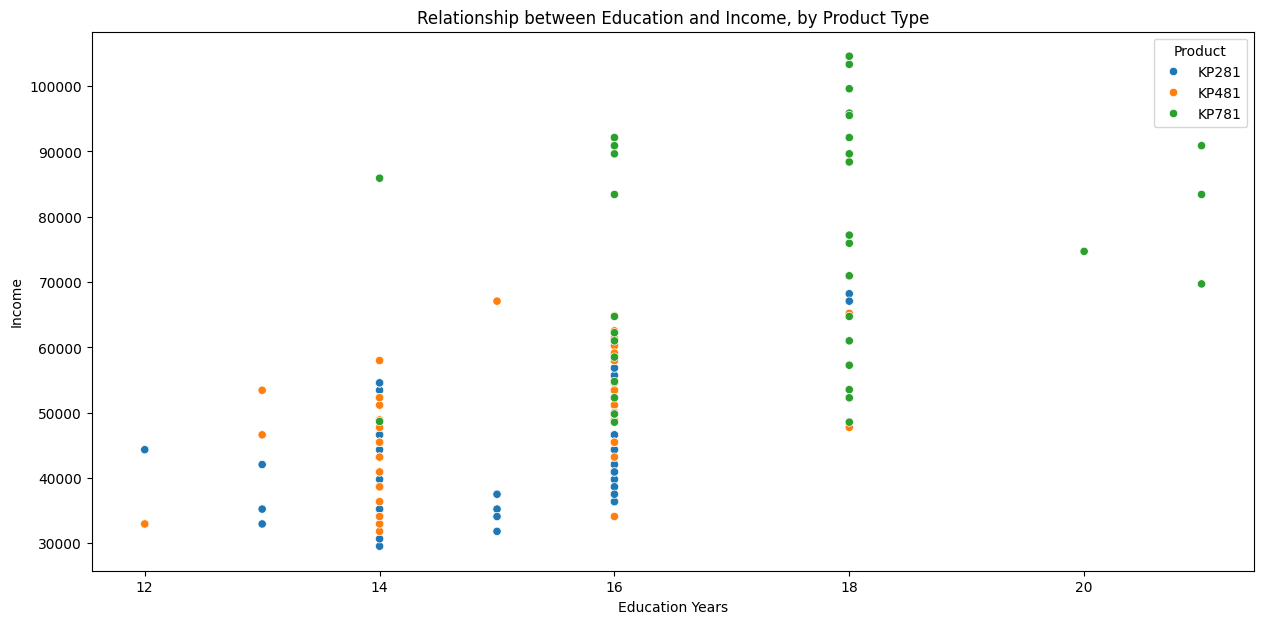

In [71]:
plt.figure(figsize = (15, 7))
sns.scatterplot(data = data, x = 'Education', y = 'Income', hue = 'Product')
plt.title('Relationship between Education and Income, by Product Type')
plt.xlabel('Education Years')
plt.show()

The scatter plot clearly depicts that customers with fewer years of education contribute more significantly to sales of the KP281 and KP481 treadmill models. Conversely, customers with higher educational attainment show a strong interest in purchasing the premium KP781 model, which accounts for a major portion of sales in that segment. Overall, customers with a moderate level of education generated the highest sales volume compared to both the lower and higher education levels.

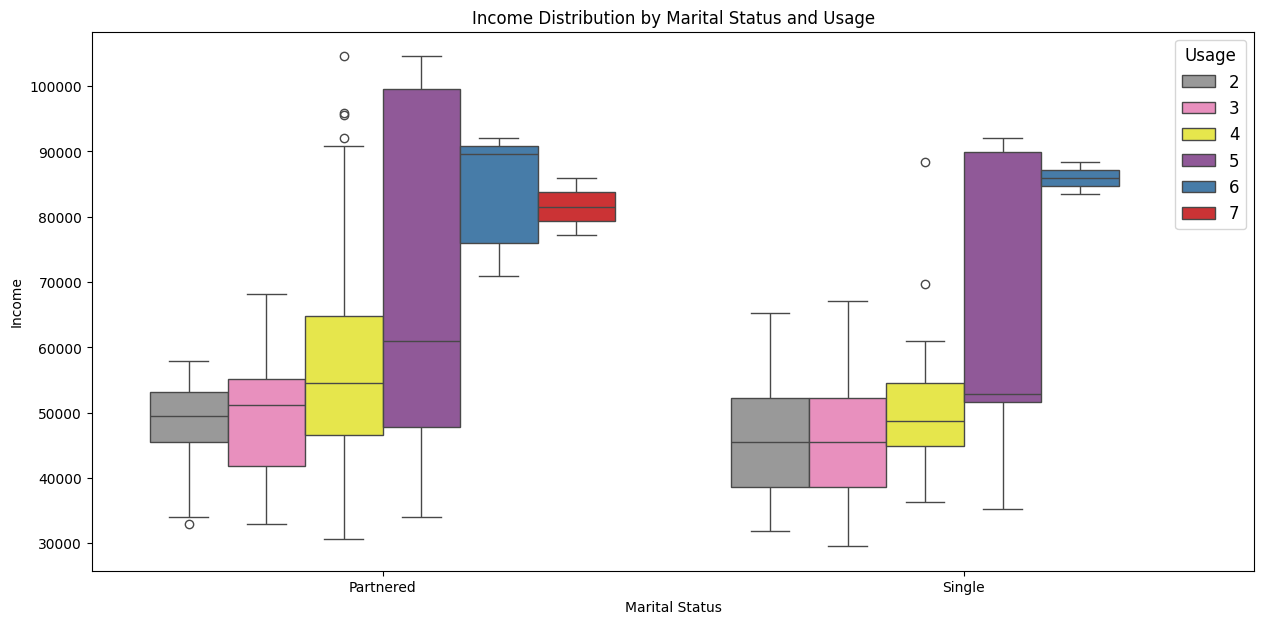

In [68]:
plt.figure(figsize = (15, 7))
sns.boxplot(data = data, x = 'MaritalStatus', y = 'Income', hue = 'Usage', palette = 'Set1_r')
plt.title('Income Distribution by Marital Status and Usage')
plt.xlabel('Marital Status')
plt.legend(title = 'Usage', fontsize = 12, title_fontsize = 12)
plt.show()

The box plot illustrates that partnered individuals utilize the treadmills more frequently than single individuals. Regarding specific usage patterns, partnered customers dominate nearly all planned daily usage frequencies, except for the "2 days per week" category. Overall, the data clearly indicates that partnered customers plan for a more extensive and committed usage of the treadmills. Additionally, a few usage outliers are present in both marital status groups.

## Missing Values & Outliers

###**Missing Values**
There are no missing values in this data.

In [72]:
data.isnull().sum()

,0
Product,0
Age,0
Gender,0
Education,0
MaritalStatus,0
Usage,0
Fitness,0
Income,0
Miles,0


### **Outliers**
Analysis of the Income Distribution by Marital Status and Usage reveals a total of seven outliers: two are concentrated for single customers, and one is five for partnered customers. Six of these outliers are upper bound outliers and only one lower bound outlier.

In [90]:
Q1 = data.groupby(['MaritalStatus', 'Usage'], observed = False)['Income'].quantile(0.25).reset_index()
Q3 = data.groupby(['MaritalStatus', 'Usage'], observed = False)['Income'].quantile(0.75).reset_index()
Q1.fillna({'Income': 0}, inplace = True)
Q3.fillna({'Income': 0}, inplace = True)

merged = Q3.merge(Q1, on = ('MaritalStatus', 'Usage'), how = 'inner')
merged.rename(columns = {'Income_x': 'Q3', 'Income_y': 'Q1'}, inplace = True)
merged['IQR'] = merged['Q3'] - merged['Q1']
merged['lower_bound'] = merged['Q1'] - 1.5 * merged['IQR']
merged['upper_bound'] = merged['Q3'] + 1.5 * merged['IQR']

comb = data.merge(merged, on = ('MaritalStatus', 'Usage'), how = 'inner')
outliers = comb[(comb['Income'] < comb['lower_bound']) | (comb['Income'] > comb['upper_bound'])]
outliers = outliers[['MaritalStatus', 'Usage', 'Income', 'lower_bound', 'upper_bound']]
outliers

,MaritalStatus,Usage,Income,lower_bound,upper_bound
86,Partnered,2,32973,33967.875,64666.875
157,Single,4,69721,30414.750,69072.750
160,Single,4,88396,30414.750,69072.750
171,Partnered,4,95866,19329.000,92097.000
173,Partnered,4,92131,19329.000,92097.000
178,Partnered,4,104581,19329.000,92097.000
179,Partnered,4,95508,19329.000,92097.000


## Probability / Contingency



In [92]:
# Conditional Probability for each Product given by MaritalStatus

cond_prob = pd.crosstab(data['MaritalStatus'], data['Product'], normalize = 'index')
cond_prob

Product,KP281,KP481,KP781
MaritalStatus,,,
Partnered,0.448598,0.336449,0.214953
Single,0.438356,0.328767,0.232877


## Business Insights

*   The data identifies the most valuable customer segment as partnered individuals with moderate education (specifically 16 years). This group drives the highest overall purchase volume, and when partnered, they exhibit the most frequent and extensive planned usage of the treadmills. This segment is likely purchasing the mid-range KP281 and KP481 models, indicating they seek a balance of value and utility for shared or consistent household use. This demographic is crucial for overall sales stability and volume.

*   Customer education level acts as a strong determinant of product choice: lower education aligns with basic models (KP281/KP481), while higher education aligns exclusively with the premium KP781 model. This segmentation means the high-margin KP781 market is clearly defined by education, but the overall low sales from the high-education segment suggest an untapped market. An opportunity exists to drive sales by highly specific, education-level targeting, promoting value and durability to the lower-educated group and performance and advanced technology to the higher-educated group.

*   Partnered customers not only contribute more to immediate sales volume but also demonstrate a significantly higher commitment to extensive, long-term treadmill usage compared to single customers. This frequent planned usage suggests that partnered buyers will have a higher Customer Lifetime Value (CLV) due to increased reliance on the product, which may translate into future purchases of maintenance services, extended warranties, or accessory sales. This insight is critical for prioritizing marketing efforts toward partnered households.





## Recommendations

*   Shift messaging away from individual performance toward shared household value, convenience, and health benefits for the family unit. Campaigns should feature the KP281 and KP481 as essential "dual-use" or "family investment" equipment. Offer bundles that include multiple user profiles, family-oriented training subscriptions, or extended warranties, specifically targeting the financial and logistical benefits appealing to partnered, budget-conscious households.

*   Focus on publications and platforms favored by highly educated professionals (e.g., industry newsletters, podcasts). Messaging must emphasize precision, advanced biometric tracking, high-end engineering, and ROI on performance. The goal is to maximize conversion in this low-volume, high-margin segment.

*   Launch a dedicated post-purchase communication stream for all customers identifying as partnered. This stream should offer timely promotions for high-margin consumables and services at 6-month and 12-month intervals. This strategy capitalizes on their extensive usage plans, positioning the company as a long-term wellness partner and maximizing revenue beyond the initial sale.





###**📈 4️⃣ Case study Summary**

## **Key Insights:**

*   KP281 is the most purchased model across almost every demographic, while KP781 attracts a smaller, specific audience (higher income, higher fitness, high-usage). Most revenue comes from KP281 sales by count, but KP781 buyers represent a higher-margin, high-LTV segment.

*   The dataset shows a skew toward younger buyers and the Low/Mid income groups account for ~85% of units sold.
Price-sensitivity and accessibility are key drivers for the main market.

*   Higher fitness levels and higher expected miles/usage correlate with a higher likelihood of selecting KP481/KP781; low-distance and low-usage customers cluster around KP281.Product recommendation can be reliably guided by Usage/Fitness signals.

*   Partnered customers buy more and plan heavier usage (higher CLV potential). Females disproportionately purchase KP281 while males are more evenly distributed across models (including KP781). Education also aligns with product tiers (higher education → KP781).Partnered households and certain gender/education segments are high-priority targets for different offers.





## **Business Recommendations:**

*   Offer EMI/0% APR, student/young-professional discounts, or low-deposit plans and run social campaigns showing affordability + value. This preserves volume while reducing price friction.
*   Implement a trade-in program, time-limited upgrade discounts, or a “use-based” loyalty credit (e.g., after 6 months of consistent logged usage). Target mid-income but high-usage users who are most likely to convert.

*   Build productized offerings by segment: Maintenance & premium bundles for KP781 starter programs for low-fitness buyers likr:
— KP781: offer Pro Loyalty (warranty, prioritized service, performance software updates) to increase CLV.
— KP281: bundle beginner coaching, guided programs, and simple warranties to increase adoption among low-fitness users.

*   Run targeted communications by persona like:
— Partnered households: family-focused messaging (shared profiles, family plans, bundling accessories).
— Female segment: tailored KP781 starter bundles and financing + female ambassador campaigns to reduce premium adoption barriers.
— High-education / high-income: technical, performance-focused messaging and white-glove buying experience.



